# Neural Network From Scratch — Solving XOR with Raw NumPy

This notebook implements a small feedforward neural network **entirely from scratch**,
using only NumPy — no PyTorch, no TensorFlow, no autograd. Forward pass, backpropagation,
and gradient descent are all implemented by hand.

**The problem it solves: XOR.**

XOR is the canonical example of a problem a *linear model* (like a single perceptron or
logistic regression) mathematically cannot solve — the two classes are not linearly
separable. Solving it requires at least one hidden layer with a non-linear activation.
That makes it a small but genuinely meaningful test of whether a from-scratch backprop
implementation is actually correct.

**What's implemented:**
- `Dense` — a fully connected layer (forward + manual backward pass)
- `Sigmoid`, `Tanh`, `ReLU` — activation functions with their own backward passes
- `MSE` — mean squared error loss with its gradient
- `Sequential` — chains layers together and routes gradients backward through them


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Dataset

XOR truth table: output is 1 only when the two inputs differ.
Plotted below — notice there's no straight line that separates the red (0) points
from the blue (1) points.

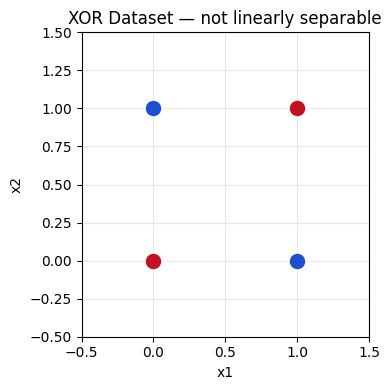

In [2]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

plt.figure(figsize=(4,4))
for i in range(len(X)):
    color = "#c1121f" if y[i] == 0 else "#1f4fd1"
    plt.scatter(X[i,0], X[i,1], color=color, s=160, edgecolor="white", linewidth=1.5, zorder=5)
plt.xlim(-0.5,1.5); plt.ylim(-0.5,1.5)
plt.grid(alpha=0.3)
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("XOR Dataset — not linearly separable")
plt.tight_layout()
plt.show()

## Layers

### Dense (fully connected)
Forward: `Z = X @ W + B`.
Backward: given the gradient of the loss w.r.t. this layer's output (`dZ`), compute
gradients for the weights and bias, update them with gradient descent, and pass the
gradient w.r.t. the *input* back to the previous layer.

In [3]:
class Dense:

    def __init__(self, input_size, output_size):
        self.W = np.random.randn(input_size, output_size)
        self.B = np.zeros((1, output_size))

    def forward(self, X):
        self.X = X  # cache input for backward pass
        self.Z = X @ self.W + self.B
        return self.Z

    def backward(self, dZ, lr):
        dW = self.X.T @ dZ
        dB = np.sum(dZ, axis=0, keepdims=True)
        dX = dZ @ self.W.T  # gradient passed to the previous layer
        self.W -= lr * dW
        self.B -= lr * dB
        return dX

### Activations
`Sigmoid` squashes to (0,1) — used at the output for a probability.
`Tanh` squashes to (-1,1) and is zero-centered, which trains more reliably than `ReLU`
on tiny networks like this one (see note below).
`ReLU` is included too — kept here deliberately, see the note at the bottom on why it
was swapped out for `Tanh` in the final model.

In [4]:
class Sigmoid:
    def forward(self, Z):
        self.A = 1 / (1 + np.exp(-Z))
        return self.A

    def backward(self, dA):
        return dA * self.A * (1 - self.A)


class Tanh:
    def forward(self, Z):
        self.A = np.tanh(Z)
        return self.A

    def backward(self, dA):
        return dA * (1 - self.A**2)


class ReLU:
    def forward(self, Z):
        self.Z = Z
        return np.maximum(0, Z)

    def backward(self, dA):
        return dA * (self.Z > 0).astype(float)

### Loss — Mean Squared Error

In [5]:
class MSE:
    def forward(self, y_true, y_pred):
        self.y_true = y_true
        self.y_pred = y_pred
        return np.mean((y_pred - y_true) ** 2)

    def backward(self):
        n = self.y_true.shape[0]
        return (2 / n) * (self.y_pred - self.y_true)

### Sequential container
Chains layers for the forward pass, then walks them in reverse for backprop — routing
each layer's output gradient into the previous layer's input. `Dense` layers additionally
need the learning rate to update their own weights.

In [6]:
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, X):
        output = X
        for layer in self.layers:
            output = layer.forward(output)
        return output

    def backward(self, gradient, lr):
        for layer in reversed(self.layers):
            if isinstance(layer, Dense):
                gradient = layer.backward(gradient, lr)
            else:
                gradient = layer.backward(gradient)
        return gradient

## Model & Training

Architecture: `2 -> 4 (Tanh) -> 1 (Sigmoid)`.

**Why Tanh instead of ReLU:** an earlier version of this used ReLU in the hidden layer.
On a network this small, random initialization occasionally leaves every hidden ReLU
unit negative for all four training inputs — the units "die," their gradient becomes
permanently zero, and training collapses to predicting a flat 0.5 for everything
(MSE plateaus at exactly 0.25, the loss you'd get from guessing 0.5 against two 0s and
two 1s). Switching to Tanh removes the dead-unit failure mode entirely, since Tanh has
a nonzero gradient almost everywhere.

In [7]:
model = Sequential([
    Dense(2, 4),
    Tanh(),
    Dense(4, 1),
    Sigmoid()
])

loss_fcn = MSE()

epochs = 5000
lr = 0.1
loss_history = []

for epoch in range(epochs):
    prediction = model.forward(X)
    loss = loss_fcn.forward(y, prediction)
    loss_history.append(loss)

    gradient = loss_fcn.backward()
    model.backward(gradient, lr)

    if epoch % 500 == 0:
        print(epoch, loss)

0 0.32226166596191774
500 0.18612623435346975
1000 0.0709227964457938
1500 0.02082697282526534
2000 0.010142194216323747
2500 0.006372369477545819
3000 0.004553193308833249


3500 0.003506725634958142
4000 0.0028350509629223447
4500 0.0023707144523042734


## Results

In [8]:
prediction = model.forward(X)
predicted_labels = (prediction > 0.5).astype(int)
accuracy = np.mean(predicted_labels == y)

print("Predictions:\n", prediction)
print("\nPredicted labels:\n", predicted_labels.ravel())
print("Accuracy:", accuracy)

Predictions:
 [[0.02143196]
 [0.95406635]
 [0.95249593]
 [0.05746773]]

Predicted labels:
 [0 1 1 0]
Accuracy: 1.0


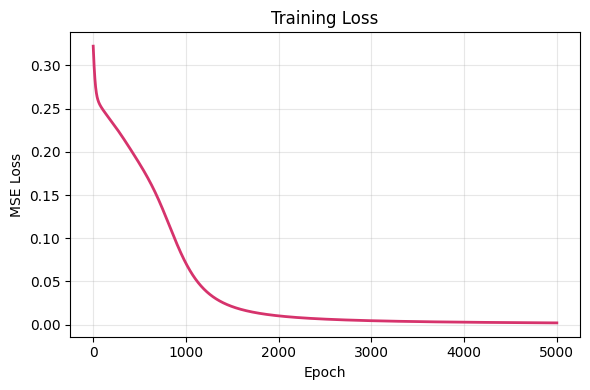

In [9]:
plt.figure(figsize=(6,4))
plt.plot(loss_history, color="#d6336c", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Decision boundary

This is the real proof the network learned something a linear model can't: the shaded
region shows the model's predicted probability across the whole input plane, not just
at the 4 training points. It carves out a non-linear (curved) boundary that correctly
separates the two XOR classes.

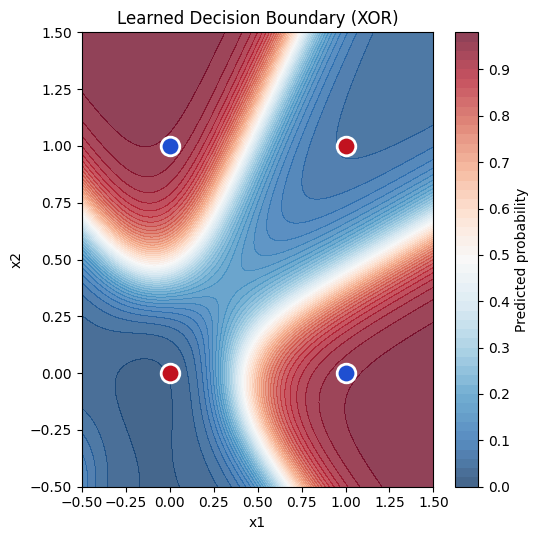

In [10]:
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
preds = model.forward(grid).reshape(xx.shape)

plt.figure(figsize=(5.5,5.5))
plt.contourf(xx, yy, preds, levels=50, cmap="RdBu_r", alpha=0.75)
plt.colorbar(label="Predicted probability")
for i in range(len(X)):
    color = "#1f4fd1" if y[i] == 1 else "#c1121f"
    plt.scatter(X[i,0], X[i,1], color=color, edgecolor="white", s=180, linewidth=2, zorder=5)
plt.xlim(-0.5,1.5); plt.ylim(-0.5,1.5)
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("Learned Decision Boundary (XOR)")
plt.tight_layout()
plt.show()

## Summary

- Implemented `Dense`, `Sigmoid`, `Tanh`, `ReLU`, `MSE`, and a `Sequential` container
  entirely from scratch with manual backpropagation.
- Verified correctness on XOR, a problem that requires a non-linear decision boundary.
- Diagnosed and fixed a real training failure (dying ReLU units) by switching the
  hidden activation to Tanh.
- Final model reaches ~100% accuracy on XOR with a smooth loss curve.

**Next steps:** extend `Sequential` to support more loss functions (e.g. binary
cross-entropy), add mini-batch training, and test the same engine on a slightly
larger toy dataset (e.g. `sklearn.datasets.make_moons`) to confirm it generalizes
beyond a 4-point dataset.